In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import copy
import uproot
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, Dataset, DataLoader, TensorDataset
import psutil, os, gc
from sklearn.preprocessing import QuantileTransformer
import csv

def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


def mem():
    p = psutil.Process(os.getpid())
    print(f"{p.memory_info().rss / 1e9:.2f} GB")

project root: /home/olivermcroy/AppliedML2026/ML_FinalProject


# data loading
labels_df = pd.read_csv(LABELS_CSV)
# Keep only the 60 GeV runs with non-zero bias (the new e/h dataset).
#runs_df = labels_df.query("bias_V == 43 and particle == 'h' and run != 577 and run != 584 and run != 592 and run != 594").copy()
runs_df = labels_df.query("run == 445 or run == 446 or run == 448 or run == 450 or run == 451 or run == 452 or run == 458 or run == 459").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    """Match either RunXXXX.root or RunXXX_EventMatch.root naming."""
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

val0_chunks, val1_chunks, run_ids, parts, biases, energies = [], [], [], [], [], []
for _, row in runs_df.iterrows():
    f = find_root_file(int(row["run"]))
    t = uproot.open(f)["data_tree"]
    n = t.num_entries

    a0 = t["val0_list_0"].array(library="np").reshape(-1, 38, 64).astype(np.uint16)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 38, 64).astype(np.uint16)
    val0_chunks.append(np.stack([a0, a1], axis=1))

    a2 = t["val1_list_0"].array(library="np").reshape(-1, 38, 64).astype(np.uint16)
    a3 = t["val1_list_1"].array(library="np").reshape(-1, 38, 64).astype(np.uint16)
    val1_chunks.append(np.stack([a2, a3], axis=1))

    run_ids.append(np.full(n, int(row["run"]),     dtype=np.int32))
    parts.append(  np.full(n, row["particle"],     dtype="U1"))
    biases.append( np.full(n, int(row["bias_V"]),  dtype=np.int32))
    energies.append( np.full(n, int(row["energy_GeV"])))
    print(f"  Run{row.run:03d}: {n:6d} events  ({row.particle}, {row.bias_V}V)")
    mem()

val0        = np.concatenate(val0_chunks, axis=0)
val1_encode = np.concatenate(val1_chunks, axis=0)
run_id      = np.concatenate(run_ids)
particle    = np.concatenate(parts)
bias_v      = np.concatenate(biases)
energy      = np.concatenate(energies)

del val0_chunks, val1_chunks, run_ids, parts, biases, energies
gc.collect()
print(f"\ntotal events: {val0.shape[0]}  shape: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")


In [ ]:
# ── run selection ───────────────────────────────────────────────────────────
labels_df = pd.read_csv(LABELS_CSV)
runs_df = labels_df.query(
    "run == 445 or run == 446 or run == 448 or run == 450 or "
    "run == 451 or run == 452 or run == 458 or run == 459"
).copy()
print("runs to load:")
print(runs_df.to_string(index=False))


# ── configuration ───────────────────────────────────────────────────────────
LEAVE_OUT_ENERGY     = 150
MAX_EVENTS_PER_RUN   = 8000
MAPPING_PATH = "/home/olivermcroy/AppliedML2026/ML_FinalProject/channelmapping.channelmapping"
print(f"\nHolding out {LEAVE_OUT_ENERGY} GeV from training")
print(f"Loading at most {MAX_EVENTS_PER_RUN} events per run")




# ── helpers ─────────────────────────────────────────────────────────────────
def find_root_file(run, data_dir=DATA_DIR):
    candidates = (list(data_dir.glob(f"Run{run}*.root"))
                + list(data_dir.glob(f"Run{run:04d}*.root")))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

def decode_tot_inplace(arr: np.ndarray) -> None:
    """
    H2GCROC ToT convention — applied IN-PLACE (no copy).
    Values > 511: mask to 10 bits, shift left by 3.
    arr must be a writable integer array.
    """
    mask = arr > 511
    arr[mask] = (arr[mask].astype(np.int32) & 0b0111111111) << 3


def subtract_pedestal_inplace(arr: np.ndarray) -> None:
    """
    Pedestal subtraction — applied IN-PLACE.
 
    arr shape: (n_events, n_boards, 38, 64)
        axis -2 (size 38) = time-sample index
        axis -1 (size 64) = channel/slot index
 
    Pedestal = mean of samples 1, 2, 3 (sample 0 is always a sync zero).
    One pedestal value per (event, board, channel) → shape (n, boards, 1, 64).
    Negative values after subtraction are clipped to 0.
 
    Works on int16 throughout — no float intermediate array is created.
    The temporary pedestal array costs only  n_events * n_boards * 64 * 2 bytes
    (≈ 57 MB for 56 000 events with 4 boards), then is immediately freed.
    """
    # Round-mean over 3 samples -> still fits in int16 (max ~341 per channel)
    ped = arr[:, :, 1:4, :].sum(axis=2, keepdims=True)   # int32 to avoid overflow
    ped = ((ped + 1) // 3).astype(np.int16)               # integer round-divide
    arr -= ped                                             # in-place, stays int16
    del ped
    np.clip(arr, 0, None, out=arr)                        # clip negatives in-place


mapping_df = pd.read_csv(MAPPING_PATH, sep="\t")

# Detector Mapping 

CONNECTED_CHANNELS = set(
    list(range(0, 8)) +
    list(range(9, 17)) +
    list(range(18, 26)) +
    list(range(27, 35))
)

USED_HALVES_BY_VLDB = {
    0: {0, 1},
    1: {0, 1, 2, 3},
}

N_SAMPLES = 16
SLOTS_PER_HALF = 38
VALUES_PER_VLDB = 4 * SLOTS_PER_HALF   # 152

BOARD_ROWS, BOARD_COLS = 3, 2
BOARD_H, BOARD_W = 4, 8



def normalize_half(asic, half):
    if half in (2, 3):
        return half
    if half in (0, 1) and asic in (0, 1):
        return 2 * asic + half
    raise ValueError(f"Bad ASIC/HALF combination: ASIC={asic}, HALF={half}")


def channel_to_raw_index(half_global, ch):
    if ch <= 17:
        slot = ch + 1
    else:
        slot = ch + 2

    return half_global * SLOTS_PER_HALF + slot


def flip_selected_boards(row, col):

    board_row = row // BOARD_H
    board_col = col // BOARD_W

    if (board_row, board_col) not in {(0,1), (1,1), (2,0)}:
        return row, col

    r0 = board_row * BOARD_H
    c0 = board_col * BOARD_W

    local_r = row - r0
    local_c = col - c0

    return r0 + (BOARD_H - 1 - local_r), col


def load_detector_mapping(mapping_file):

    mapping = []

    max_row = -1
    max_col = -1

    with open(mapping_file, "r") as f:

        reader = csv.DictReader(f, delimiter="\t")

        for line in reader:

            row  = int(line["ROW"])
            col  = int(line["COL"])
            vldb = int(line["VLDB"])
            asic = int(line["ASIC"])
            half = int(line["HALF"])
            ch   = int(line["CHANNEL"])

            max_row = max(max_row, row)
            max_col = max(max_col, col)

            if ch not in CONNECTED_CHANNELS:
                continue

            half_global = normalize_half(asic, half)

            if half_global not in USED_HALVES_BY_VLDB.get(vldb, {0,1,2,3}):
                continue

            raw_index = channel_to_raw_index(
                half_global,
                ch
            )

            row, col = flip_selected_boards(
                row,
                col
            )

            mapping.append(
                (vldb, raw_index, row, col)
            )

    n_rows = max_row + 1
    n_cols = max_col + 1

    return mapping, n_rows, n_cols


MAPPING, DET_ROWS, DET_COLS = load_detector_mapping(
    MAPPING_PATH
)

print(
    f"Detector geometry: "
    f"{DET_ROWS} x {DET_COLS}"
)
print(mapping_df)


def event_to_detector_image(
    fpga0,
    fpga1,
    mapping,
    n_rows,
    n_cols
):
    """
    fpga0 shape:
        (16,152)

    fpga1 shape:
        (16,152)

    returns:
        (16,12,16)
    """

    img = np.zeros(
        (
            N_SAMPLES,
            n_rows,
            n_cols
        ),
        dtype=np.float32
    )

    for vldb, raw_index, row, col in mapping:

        if vldb == 0:
            img[:, row, col] = fpga0[:, raw_index]
        else:
            img[:, row, col] = fpga1[:, raw_index]

    return img


runs to load:
 run  energy_GeV particle  bias_V
 445         150        h       0
 446         200        h       0
 448         300        h       0
 450         100        h       0
 451          80        h       0
 452          60        h       0
 458         250        h       0
 459         350        h       0

Holding out 150 GeV from training
Loading at most 8000 events per run
Detector geometry: 12 x 16
     ROW  COL  VLDB  ASIC  HALF  CHANNEL
0      0    0     1     1     0        2
1      0    1     1     1     0        6
2      0    2     1     1     0       12
3      0    3     1     1     0       14
4      0    4     1     1     0       21
..   ...  ...   ...   ...   ...      ...
187   11   11     0     0     1       21
188   11   12     0     0     1       14
189   11   13     0     0     1       12
190   11   14     0     0     1        6
191   11   15     0     0     1        2

[192 rows x 6 columns]



Loading TRAIN set (7 runs, excluding 150 GeV)…
  Run 446:   8000 events (h, 200 GeV)
1.46 GB
  Run 448:   8000 events (h, 300 GeV)
1.73 GB
  Run 450:   8000 events (h, 100 GeV)
2.03 GB
  Run 451:   8000 events (h, 80 GeV)
2.23 GB
  Run 452:   8000 events (h, 60 GeV)
2.41 GB
  Run 458:   8000 events (h, 250 GeV)
2.63 GB
  Run 459:   8000 events (h, 350 GeV)
2.84 GB

Total events: 56000
Detector tensor shape: (56000, 2, 12, 16, 16)

Loading VAL set (8 runs, all energies)…
  Run 445:   8000 events (h, 150 GeV)
3.03 GB
  Run 446:   8000 events (h, 200 GeV)
3.23 GB
  Run 448:   8000 events (h, 300 GeV)
3.44 GB
  Run 450:   8000 events (h, 100 GeV)
3.67 GB
  Run 451:   8000 events (h, 80 GeV)
3.87 GB
  Run 452:   8000 events (h, 60 GeV)
4.04 GB
  Run 458:   8000 events (h, 250 GeV)
4.25 GB
  Run 459:   8000 events (h, 350 GeV)
4.46 GB

Total events: 64000
Detector tensor shape: (64000, 2, 12, 16, 16)

Final shapes:  X_train (56000, 2, 12, 16, 16)  X_val (64000, 2, 12, 16, 16)
3.99 GB

DataL

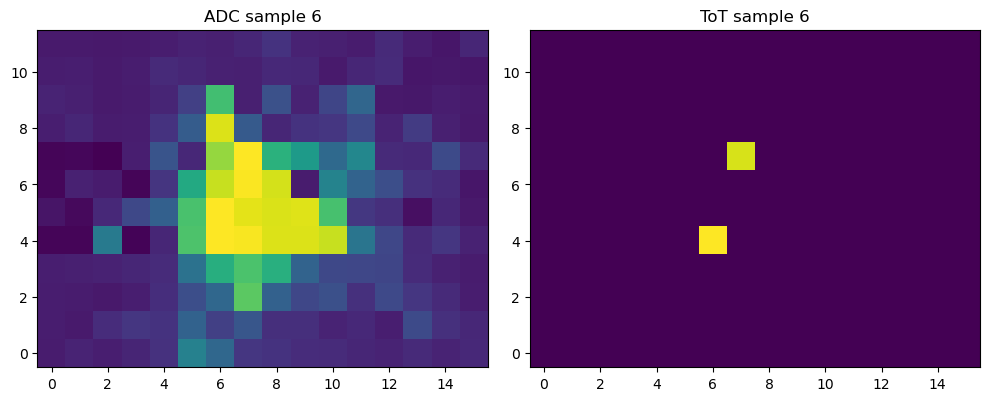

In [ ]:
PEDESTAL_START = 0
PEDESTAL_STOP = 3
N_LOWEST = 3

def subtract_pedestal(event_data):
    early = event_data[PEDESTAL_START:PEDESTAL_STOP, :]
    lowest = np.partition(early, N_LOWEST - 1, axis=0)[:N_LOWEST, :]
    pedestal = np.mean(lowest, axis=0, keepdims=True)
    return event_data - pedestal


# main loading function
    runs_df: pd.DataFrame,
    max_events_per_run: int = MAX_EVENTS_PER_RUN
):
    """
    Returns detector-image tensors.

    X shape:
        (N, 2, 12, 16, 16)

    Dimensions:
        channel 0 = ADC
        channel 1 = ToT

        detector rows = 12
        detector cols = 16

        time samples = 16
    """

    X_chunks = []

    run_ids = []
    parts = []
    biases = []
    energies = []

    for _, row in runs_df.iterrows():

        f = find_root_file(int(row["run"]))
        t = uproot.open(f)["data_tree"]

        n = min(
            t.num_entries,
            max_events_per_run
        )

        # load raw data arrays

        adc0 = (t["val0_list_0"].array(library="np",entry_stop=n).reshape(n,N_SAMPLES,VALUES_PER_VLDB).astype(np.int16))

        adc1 = (t["val0_list_1"].array(library="np",entry_stop=n).reshape(n,N_SAMPLES,VALUES_PER_VLDB).astype(np.int16))

        tot0 = (t["val1_list_0"].array(library="np",entry_stop=n).reshape(n,N_SAMPLES,VALUES_PER_VLDB).astype(np.int16))

        tot1 = (t["val1_list_1"].array(library="np",entry_stop=n).reshape(n,N_SAMPLES,VALUES_PER_VLDB).astype(np.int16))

        decode_tot_inplace(tot0)
        decode_tot_inplace(tot1)
        adc_images = np.empty(
            (
                n,
                N_SAMPLES,
                DET_ROWS,
                DET_COLS
            ),
            dtype=np.float32
        )

        tot_images = np.empty_like(adc_images)


        for i_evt in range(n):

            adc_evt0 = subtract_pedestal(
                adc0[i_evt].astype(np.float32)
            )

            adc_evt1 = subtract_pedestal(
                adc1[i_evt].astype(np.float32)
            )

            tot_evt0 = subtract_pedestal(
                tot0[i_evt].astype(np.float32)
            )

            tot_evt1 = subtract_pedestal(
                tot1[i_evt].astype(np.float32)
            )

            adc_images[i_evt] = event_to_detector_image(
                adc_evt0,
                adc_evt1,
                MAPPING,
                DET_ROWS,
                DET_COLS
            )

            tot_images[i_evt] = event_to_detector_image(
                tot_evt0,
                tot_evt1,
                MAPPING,
                DET_ROWS,
                DET_COLS
            )

        # stack ADC + ToT

        X_run = np.stack(
            [
                adc_images,
                tot_images
            ],
            axis=1
        )

        # Current:
        # (n, 2, 16, 12, 16)

        X_run = np.transpose(
            X_run,
            (
                0,  # events
                1,  # adc/tot
                3,  # rows
                4,  # cols
                2   # time
            )
        )

        # Final:
        # (n, 2, 12, 16, 16)

        X_chunks.append(X_run)

        run_ids.append(np.full(n, int(row["run"]), dtype=np.int32))

        parts.append(np.full(n, row["particle"], dtype="U1"))

        biases.append(np.full(n, int(row["bias_V"]), dtype=np.int32))

        energies.append(np.full(n, int(row["energy_GeV"])))

        print(
            f"  Run {row.run:03d}: "
            f"{n:6d} events "
            f"({row.particle}, "
            f"{row.energy_GeV} GeV)"
        )

        mem()

        del adc0
        del adc1
        del tot0
        del tot1
        del adc_images
        del tot_images

        gc.collect()

    
    # Combine runs

    X = np.concatenate(
        X_chunks,
        axis=0
    )

    del X_chunks
    gc.collect()

    energy = np.concatenate(
        energies
    ).astype(np.float32)

    run_id = np.concatenate(
        run_ids
    )

    particle = np.concatenate(
        parts
    )

    bias_v = np.concatenate(
        biases
    )

    del energies
    del run_ids
    del parts
    del biases

    gc.collect()

    print(
        f"\nTotal events: {X.shape[0]}"
    )

    print(
        f"Detector tensor shape: "
        f"{X.shape}"
    )

    y = np.log1p(
        energy
    )

    return (X, y, energy, run_id, particle, bias_v) 
 

#split data and load
train_runs_df = runs_df[runs_df.energy_GeV != LEAVE_OUT_ENERGY].copy()
val_runs_df   = runs_df.copy()

print(f"\nLoading TRAIN set ({len(train_runs_df)} runs, excluding {LEAVE_OUT_ENERGY} GeV)…")
X_train, y_train, *_ = load_runs(train_runs_df, MAX_EVENTS_PER_RUN)

print(f"\nLoading VAL set ({len(val_runs_df)} runs, all energies)…")
X_val, y_val, *_ = load_runs(val_runs_df, MAX_EVENTS_PER_RUN)

# convert dtype
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)

mean = X_train.mean(axis=(0, 2, 3, 4), keepdims=True)
std  = X_train.std(axis=(0, 2, 3, 4), keepdims=True)
std[std == 0] = 1.0

X_train -= mean
X_train /= std

X_val -= mean
X_val /= std

gc.collect()

print(f"\nFinal shapes:  X_train {X_train.shape}  X_val {X_val.shape}")
mem()

def to_tensors(X, y):
    return (
        torch.from_numpy(np.ascontiguousarray(X)),
        torch.from_numpy(y)
    )

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=True
) 
 
print("\nDataLoaders ready.")
mem()


evt = X_train[0]

adc_img = evt[0]
tot_img = evt[1]

sample = 6

fig, ax = plt.subplots(
    1,
    2,
    figsize=(10,4)
)

ax[0].imshow(
    adc_img[:,:,sample],
    origin="lower"
)

ax[0].set_title(
    f"ADC sample {sample}"
)

ax[1].imshow(
    tot_img[:,:,sample],
    origin="lower"
)

ax[1].set_title(
    f"ToT sample {sample}"
)

plt.tight_layout()
plt.show()


from catboost import CatBoostRegressor, Pool
import shap
print(np.shape(input_data))
print(energy_test)


model_full = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',   
    eval_metric='MAE',   
    random_seed=42,
    verbose=100
)

model_full.fit(input_train, energy_train,
    eval_set=(input_test, energy_test),
    early_stopping_rounds=50
)


In [4]:
mem()

6.94 GB


In [5]:


class FoCal3DNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv3d(
                2,
                16,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.Conv3d(
                16,
                32,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d((1,2,2)),

            nn.Conv3d(
                32,
                64,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                64,
                128,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool3d(1)
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,2)
        )

    def forward(self,x):

        x = self.features(x)

        out = self.head(x)

        mu = out[:,0]
        log_sigma = out[:,1]

        return mu, log_sigma
    

def heteroscedastic_loss(mu, log_sigma, target):
    log_sigma = torch.clamp(log_sigma, min=-6.0, max=6.0)  # prevents explosion
    inv_var = torch.exp(-2 * log_sigma)
    loss = 0.5 * (target - mu)**2 * inv_var + log_sigma
    return loss.mean()

In [13]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FoCal3DNet().to(device)

n_epochs = 200
train_losses = []
val_losses = []


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

best_val_loss = np.inf
best_epoch = 0
patience = 24

history = {
    "train_loss": [],
    "val_loss": [],
    "val_mae": [],
    "lr": []
}

for epoch in range(n_epochs):


    model.train()

    train_loss = 0.0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{n_epochs}",
        leave=False
    )

    for x, y in pbar:

        x = x.cuda(non_blocking=True)
        y = y.cuda(non_blocking=True)

        optimizer.zero_grad()

        mu, log_sigma = model(x)

        loss = heteroscedastic_loss(
            mu,
            log_sigma,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        train_loss += loss.item() * x.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader.dataset)



    model.eval()

    val_loss = 0.0

    preds = []
    truths = []

    with torch.no_grad():

        for x, y in val_loader:

            x = x.cuda(non_blocking=True)
            y = y.cuda(non_blocking=True)

            mu, log_sigma = model(x)

            loss = heteroscedastic_loss(
                mu,
                log_sigma,
                y
            )

            val_loss += loss.item() * x.size(0)

            preds.append(
                mu.cpu().numpy()
            )

            truths.append(
                y.cpu().numpy()
            )

    val_loss /= len(val_loader.dataset)

    preds = np.concatenate(preds)
    truths = np.concatenate(truths)

    val_mae = np.mean(
        np.abs(preds - truths)
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch+1:03d} | "
        f"TrainLoss={train_loss:.4f} | "
        f"ValLoss={val_loss:.4f} | "
        f"ValMAE={val_mae:.4f} | "
        f"LR={current_lr:.2e}"
    )


    min_delta = 1e-4
    if val_loss < best_val_loss - min_delta:

        best_val_loss = val_loss
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            "best_model5.pt"
        )

        print(
            f"  ✓ New best model "
            f"(Val Loss={best_val_loss:.4f})"
        )

    elif epoch - best_epoch >= patience:

        print(
            f"\nEarly stopping "
            f"after epoch {epoch+1}"
        )
        break

model.load_state_dict(
    torch.load("best_model5.pt")
)

Epoch 001 | TrainLoss=1.2241 | ValLoss=-0.1162 | ValMAE=0.3539 | LR=1.00e-03
  ✓ New best model (Val Loss=-0.1162)


Epoch 002 | TrainLoss=0.2043 | ValLoss=-0.3259 | ValMAE=0.2472 | LR=1.00e-03
  ✓ New best model (Val Loss=-0.3259)


Epoch 003 | TrainLoss=0.1086 | ValLoss=-0.3215 | ValMAE=0.2211 | LR=1.00e-03


Epoch 004 | TrainLoss=0.0783 | ValLoss=-0.3539 | ValMAE=0.1950 | LR=1.00e-03
  ✓ New best model (Val Loss=-0.3539)


Epoch 005 | TrainLoss=0.0410 | ValLoss=-0.3772 | ValMAE=0.2541 | LR=1.00e-03
  ✓ New best model (Val Loss=-0.3772)


...

Epoch 091 | TrainLoss=-1.7290 | ValLoss=-0.8529 | ValMAE=0.1247 | LR=2.50e-04


Epoch 092 | TrainLoss=-1.7367 | ValLoss=-0.8491 | ValMAE=0.1224 | LR=2.50e-04


Epoch 093 | TrainLoss=-1.7406 | ValLoss=-0.7932 | ValMAE=0.1208 | LR=2.50e-04


Epoch 094 | TrainLoss=-1.7442 | ValLoss=-0.9093 | ValMAE=0.1144 | LR=2.50e-04

Early stopping after epoch 94


<All keys matched successfully>

In [14]:
model.load_state_dict(
    torch.load("best_model5.pt")
)

model.eval()

all_mu = []
all_sigma = []
all_true = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        mu, log_sigma = model(X_batch)

        sigma = torch.exp(log_sigma)

        all_mu.append(mu.cpu().numpy())
        all_sigma.append(sigma.cpu().numpy())
        all_true.append(y_batch.numpy())

mu_pred_log = np.concatenate(all_mu)
sigma_log   = np.concatenate(all_sigma)
y_true_log  = np.concatenate(all_true)


model.eval()

preds = []
sigmas = []
truths = []

with torch.no_grad():

    for x,y in val_loader:

        x = x.cuda()

        mu, log_sigma = model(x)

        preds.append(
            mu.cpu().numpy()
        )

        sigmas.append(
            np.exp(
                log_sigma.cpu().numpy()
            )
        )

        truths.append(
            y.numpy()
        )

preds = np.concatenate(preds)
sigmas = np.concatenate(sigmas)
truths = np.concatenate(truths)


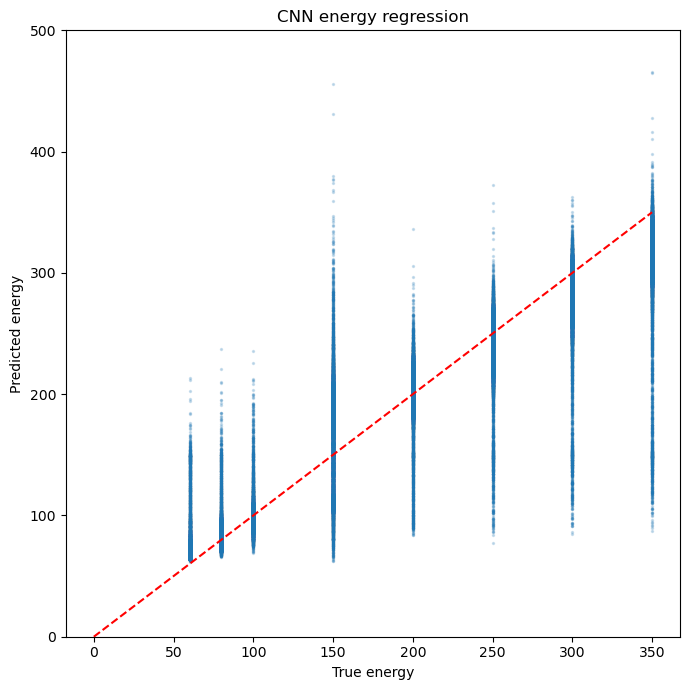

In [15]:
energy_pred = np.expm1(mu_pred_log)
energy_true = np.expm1(y_true_log)
energy_sigma = np.exp(mu_pred_log) * sigma_log


plt.figure(figsize=(7,7))

plt.scatter(
    energy_true,
    energy_pred,
    s=2,
    alpha=0.2
)

lims = [0, 350
    #min(energy_true.min(), energy_pred.min()),
    #max(energy_true.max(), energy_pred.max())
]

plt.plot(lims, lims, "r--")

plt.xlabel("True energy")
plt.ylabel("Predicted energy")
plt.title("CNN energy regression")
plt.ylim(0,500)

plt.tight_layout()
plt.show()

In [16]:
relative_mae = np.mean(
    np.abs(energy_pred - energy_true) / energy_true
)

print(f"Relative MAE: {100*relative_mae:.2f}%")

mask2 = energy_true > 0

mae = np.mean(
    np.abs(energy_pred - energy_true)
)

print(f"MAE: {mae:.2f}")


Relative MAE: 13.94%
MAE: 23.61


In [17]:
pred_energy = np.expm1(preds)
true_energy = np.expm1(truths)

for e in np.unique(energy_true):
    mask = energy_true == e
    mae = np.mean(
        np.abs(pred_energy[mask] - true_energy[mask])
    )
    print(f"{int(e):3d} GeV : MAE = {mae:.3f} GeV")

 59 GeV : MAE = 14.828 GeV
 80 GeV : MAE = 9.163 GeV
 99 GeV : MAE = 7.331 GeV
149 GeV : MAE = 40.201 GeV
199 GeV : MAE = 17.010 GeV
250 GeV : MAE = 22.163 GeV
300 GeV : MAE = 31.150 GeV
350 GeV : MAE = 47.044 GeV


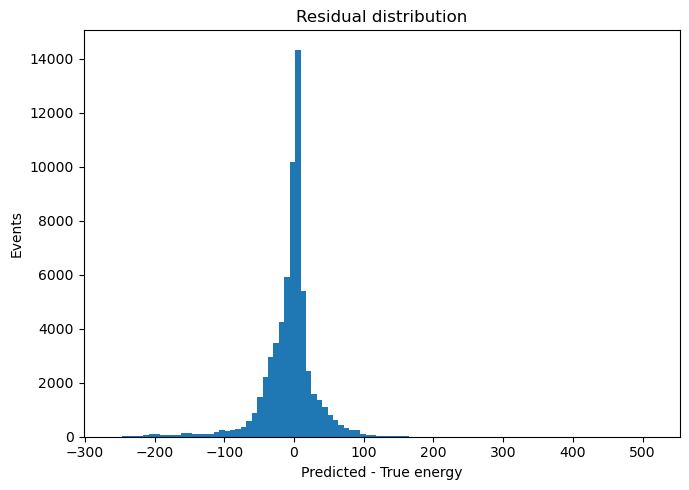

38.407097
23.611198


In [18]:
residual = energy_pred - energy_true

plt.figure(figsize=(7,5))

plt.hist(
    residual,
    bins=100
)

plt.xlabel("Predicted - True energy")
plt.ylabel("Events")
plt.title("Residual distribution")

plt.tight_layout()
plt.show()

print(np.std(residual))
print(np.mean(np.abs(residual)))

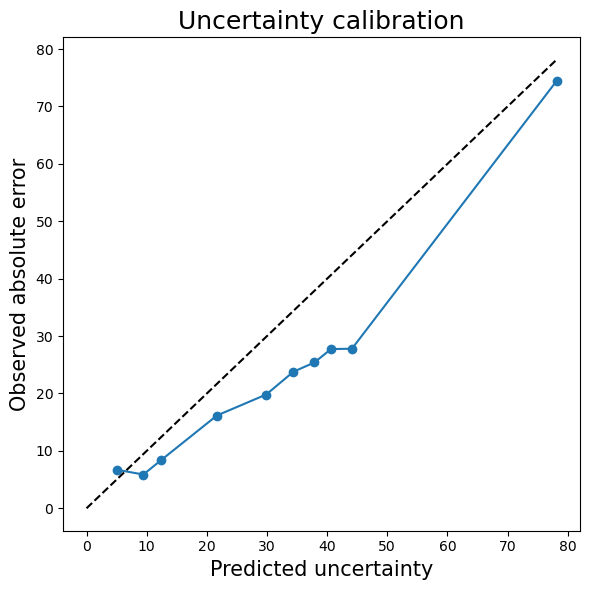

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [19]:
abs_error = np.abs(
    energy_pred - energy_true
)

bins = np.quantile(
    energy_sigma,
    np.linspace(0, 1, 11)
)

mean_sigma = []
mean_error = []

for i in range(len(bins)-1):

    mask = (
        (energy_sigma >= bins[i]) &
        (energy_sigma < bins[i+1])
    )

    mean_sigma.append(
        energy_sigma[mask].mean()
    )

    mean_error.append(
        abs_error[mask].mean())



plt.figure(figsize=(6,6))

plt.plot(
    mean_sigma,
    mean_error,
    "o-"
)

mx = max(
    max(mean_sigma),
    max(mean_error)
)

plt.plot([0,mx],[0,mx],"k--")

plt.xlabel("Predicted uncertainty", fontsize = 15)
plt.ylabel("Observed absolute error", fontsize = 15)

plt.title("Uncertainty calibration", fontsize = 18)

plt.tight_layout()
plt.show()
print(np.linspace(0, 1, 11))

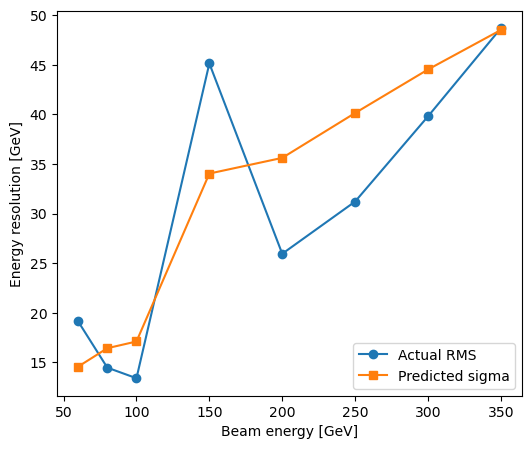

In [21]:

model.eval()
all_mu = []
all_log_sigma = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        mu, log_sigma = model(X_batch)
        all_mu.append(mu.cpu().numpy())
        all_log_sigma.append(log_sigma.cpu().numpy())
        all_true.append(y_batch.numpy())

mu_pred_log    = np.concatenate(all_mu)
log_sigma_pred = np.concatenate(all_log_sigma)
y_true_log     = np.concatenate(all_true)

true_energy = np.expm1(y_true_log)
pred_energy = np.expm1(mu_pred_log)

# σ in log1p(E) space → propagate to GeV via chain rule: dE/dx = exp(x) = E+1
sigma_pred_log = np.exp(log_sigma_pred)
sigma_energy   = sigma_pred_log * (pred_energy + 1)

energies   = np.sort(np.unique(true_energy))
actual_rms = []
pred_sigma = []

for E in energies:
    mask = true_energy == E
    rms      = np.std(pred_energy[mask] - true_energy[mask])
    mean_sig = np.mean(sigma_energy[mask])
    actual_rms.append(rms)
    pred_sigma.append(mean_sig)

actual_rms = np.array(actual_rms)
pred_sigma = np.array(pred_sigma)

plt.figure(figsize=(6, 5))
plt.plot(energies, actual_rms, "o-", label="Actual RMS")
plt.plot(energies, pred_sigma, "s-", label="Predicted sigma")
plt.xlabel("Beam energy [GeV]")
plt.ylabel("Energy resolution [GeV]")
plt.legend()
plt.show()

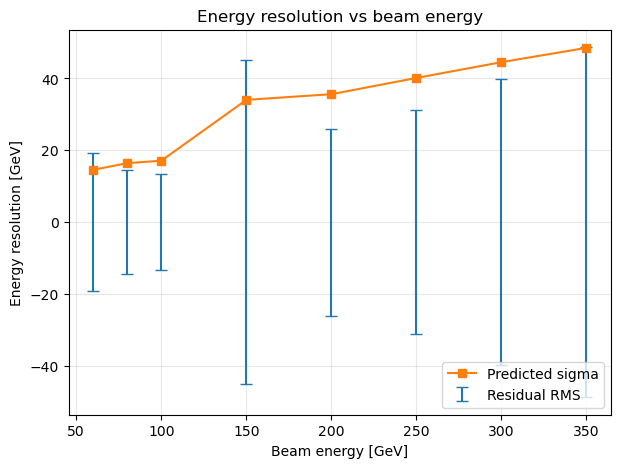

In [23]:
plt.figure(figsize=(7,5))

# convert lists to arrays (safe even if already arrays)
energies = np.array(energies)
actual_rms = np.array(actual_rms)
pred_sigma = np.array(pred_sigma)

# sort (important for clean curves)
idx = np.argsort(energies)
energies = energies[idx]
actual_rms = actual_rms[idx]
pred_sigma = pred_sigma[idx]

# errorbars = actual resolution
plt.errorbar(
    energies,
    np.zeros_like(energies),   # centered at 0 bias (since we plot resolution, not bias)
    yerr=actual_rms,
    fmt=' ',
    capsize=4,
    label="Residual RMS"
)

# predicted sigma curve
plt.plot(
    energies,
    pred_sigma,
    's-',
    label="Predicted sigma"
)

plt.xlabel("Beam energy [GeV]")
plt.ylabel("Energy resolution [GeV]")
plt.title("Energy resolution vs beam energy")
plt.legend(loc ='lower right')
plt.grid(True, alpha=0.3)

plt.show()

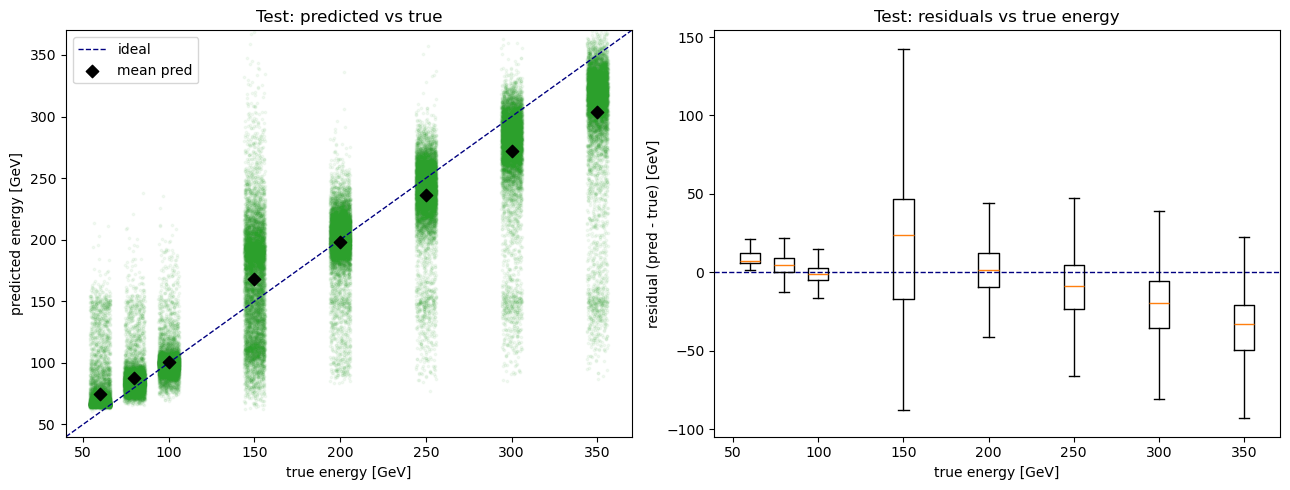

test MAE :   23.61 GeV
test RMSE:   38.86 GeV
test R^2 :  0.8489

per-energy summary:
   E[GeV]      n  mean pred     bias     std  sigma/E
       59   8000       74.8    +14.8    19.1    0.319
       80   8000       87.4     +7.4    14.5    0.181
       99   8000      100.9     +0.9    13.4    0.134
      149   8000      168.1    +18.1    45.1    0.301
      199   8000      198.5     -1.5    26.0    0.130
      250   8000      236.6    -13.4    31.2    0.125
      300   8000      272.3    -27.7    39.8    0.133
      350   8000      303.8    -46.2    48.7    0.139


In [24]:
from sklearn.metrics import r2_score

mae  = np.mean(np.abs(energy_pred - energy_true))
rmse = np.sqrt(np.mean((energy_pred - energy_true) ** 2))
r2   = r2_score(energy_true, energy_pred)
energies_sorted = np.array(sorted(np.unique(energy_true)))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

lo, hi = energy_true.min() - 20, energy_true.max() + 20
ax[0].plot([lo, hi], [lo, hi], "--", color="navy", lw=1, label="ideal")
ax[0].scatter(energy_true + np.random.uniform(-6, 6, len(energy_true)), energy_pred,
              s=3, alpha=0.05, color="#2ca02c")
ax[0].scatter(energies_sorted, [energy_pred[energy_true == E].mean() for E in energies_sorted],
              color="black", marker="D", s=40, zorder=5, label="mean pred")
ax[0].set_xlabel("true energy [GeV]"); ax[0].set_ylabel("predicted energy [GeV]")
ax[0].set_title("Test: predicted vs true"); ax[0].legend(loc="upper left")
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)

ax[1].axhline(0, color="navy", ls="--", lw=1)
parts = [(energy_pred - energy_true)[energy_true == E] for E in energies_sorted]
ax[1].boxplot(parts, positions=energies_sorted, widths=12, showfliers=False,
              manage_ticks=False)
ax[1].set_xlabel("true energy [GeV]"); ax[1].set_ylabel("residual (pred - true) [GeV]")
ax[1].set_title("Test: residuals vs true energy")
plt.tight_layout(); plt.show()

print(f"test MAE :  {mae:6.2f} GeV")
print(f"test RMSE:  {rmse:6.2f} GeV")
print(f"test R^2 :  {r2:6.4f}")
print("\nper-energy summary:")
print(f"  {'E[GeV]':>7} {'n':>6} {'mean pred':>10} {'bias':>8} {'std':>7} {'sigma/E':>8}")
for E in energies_sorted:
    m = energy_true == E
    mp, sd = energy_pred[m].mean(), energy_pred[m].std()
    print(f"  {int(E):>7} {m.sum():>6} {mp:>10.1f} {mp - E:>+8.1f} {sd:>7.1f} {sd / E:>8.3f}")